# Model Evaluation and Visualization

يهدف هذا الملف إلى تحليل أداء النماذج المدربة بصريًا ومقارنة نتائجها باستخدام مقاييس مناسبة لمشكلة الاحتيال المالي.

## 1. استيراد المكتبات (Import Libraries)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    roc_curve, 
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# إعدادات الرسوم البيانية
%matplotlib inline
sns.set_theme(style="whitegrid")

## 2. تحميل البيانات (Load Data)

سنقوم بتحميل البيانات وتقسيمها بنفس الطريقة المستخدمة في الملفات السابقة لضمان اتساق النتائج.

In [6]:
df = pd.read_csv("../data/creditcard.csv")

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_test shape: {X_test.shape}")
print(f"Class distribution in test set:\n{y_test.value_counts()}")

X_test shape: (56962, 30)
Class distribution in test set:
Class
0    56864
1       98
Name: count, dtype: int64


## 3. تدريب النماذج (Model Training)

بما أن النماذج لم يتم حفظها كملفات في الخطوة السابقة، سنقوم بإعادة تدريبها هنا بسرعة باستخدام نفس الإعدادات.

In [13]:
# 1. Logistic Regression
lr_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(random_state=42))
])
lr_model.fit(X_train, y_train)

# 2. XGBoost
xgb_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("classifier", XGBClassifier(random_state=42, eval_metric='logloss'))
])
xgb_model.fit(X_train, y_train)

print("Models re-trained successfully.")

Models re-trained successfully.


## 4. مصفوفة الارتباك (Confusion Matrix)

تعتبر مصفوفة الارتباك من أهم الأدوات لتقييم أداء النموذج في حالات البيانات غير المتوازنة.
- **FP (False Positives):** إنذارات كاذبة (عملية سليمة تم تصنيفها كاحتيال).
- **FN (False Negatives):** أخطر شيء، وهو احتيال لم يتم اكتشافه.

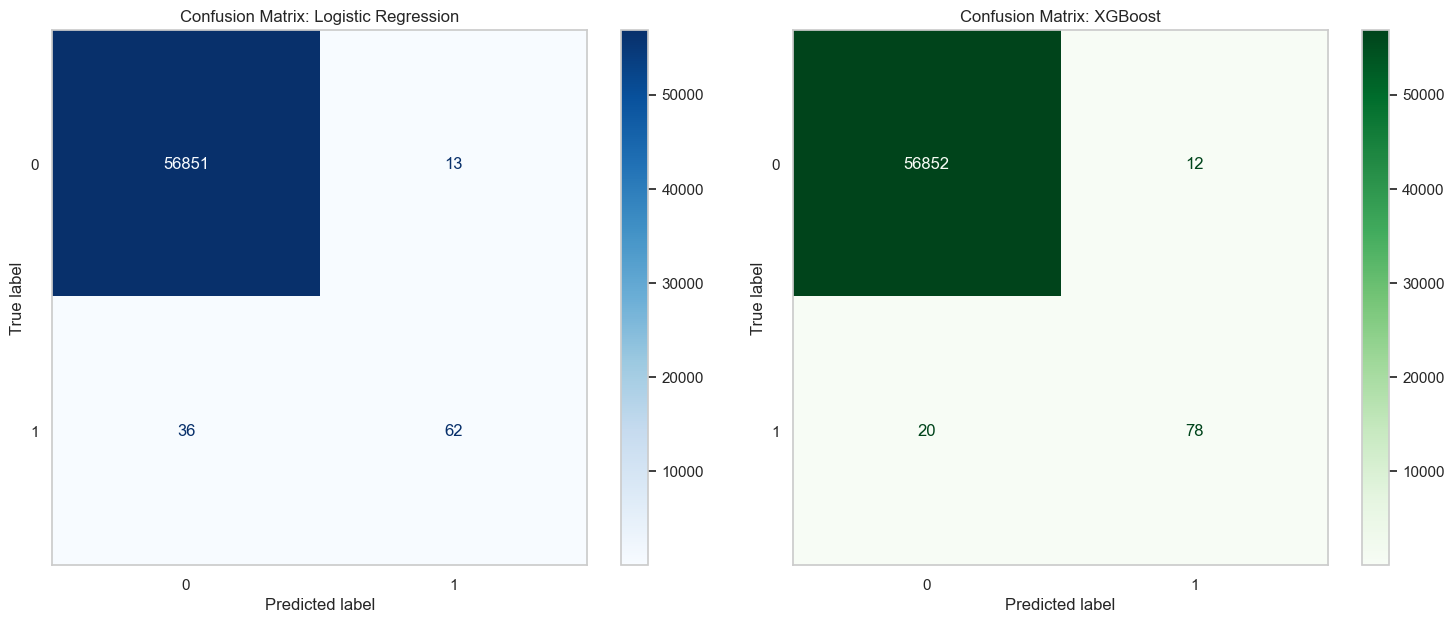

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Logistic Regression CM
ConfusionMatrixDisplay.from_estimator(lr_model, X_test, y_test, ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix: Logistic Regression')
axes[0].grid(False)

# XGBoost CM
ConfusionMatrixDisplay.from_estimator(xgb_model, X_test, y_test, ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title('Confusion Matrix: XGBoost')
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 5. منحنى خصائص تشغيل المستقبِل (ROC Curve)

يوضح هذا الرسم قدرة النموذج على الفصل بين الفئات (احتيال مقابل سليم) عند مستويات مختلفة من الاحتمالية.

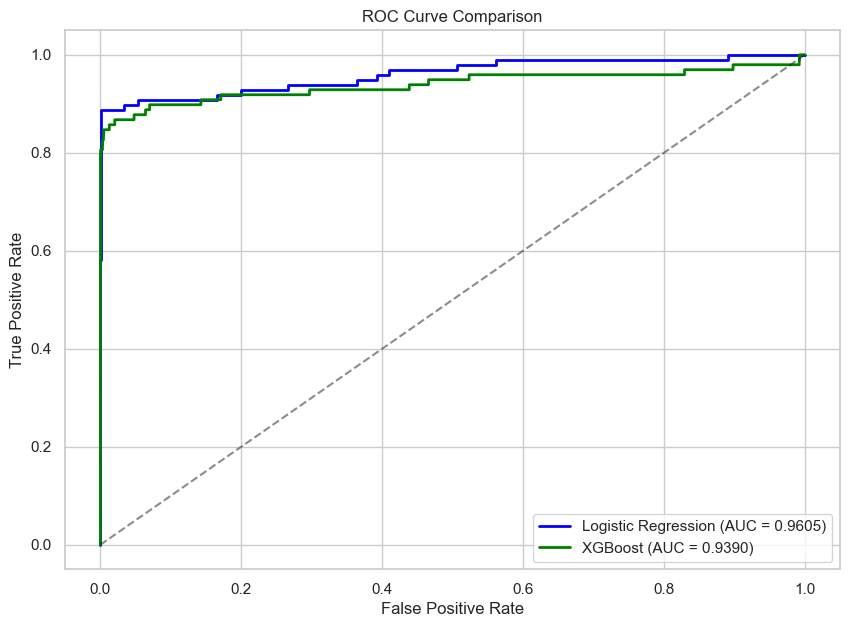

In [15]:
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

plt.figure(figsize=(10, 7))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})', color='blue', lw=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})', color='green', lw=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.show()

## 6. منحنى الدقة والاستدعاء (Precision–Recall Curve)

بما أن البيانات غير متوازنة بشكل حاد، فإن هذا الرسم يعتبر أكثر دقة وأهمية من ROC في تقييم جودة اكتشاف الاحتيال.

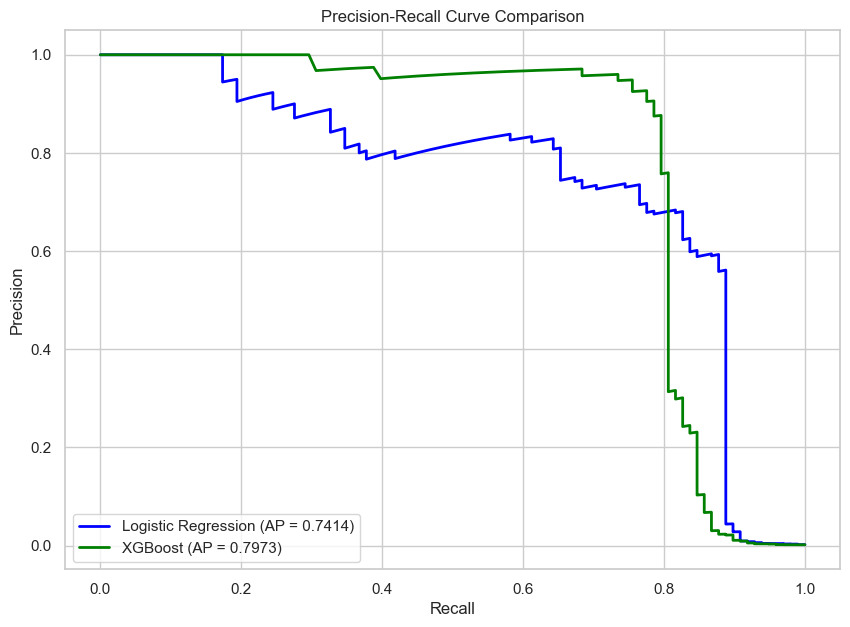

In [16]:
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob_lr)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)

ap_lr = average_precision_score(y_test, y_prob_lr)
ap_xgb = average_precision_score(y_test, y_prob_xgb)

plt.figure(figsize=(10, 7))
plt.plot(rec_lr, prec_lr, label=f'Logistic Regression (AP = {ap_lr:.4f})', color='blue', lw=2)
plt.plot(rec_xgb, prec_xgb, label=f'XGBoost (AP = {ap_xgb:.4f})', color='green', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend(loc='lower left')
plt.show()

## 7. مقارنة مرئية للمقاييس (Visual Metrics Comparison)

سنقوم بمقارنة المقاييس الأساسية للنموذجين في رسم بياني واحد.

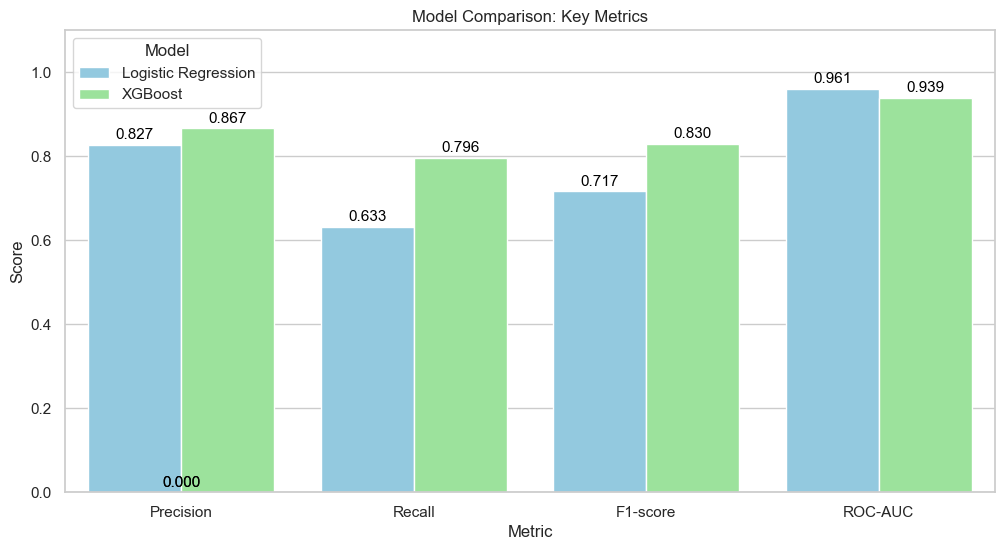

In [17]:
y_pred_lr = lr_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

metrics_data = {
    'Metric': ['Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    'Logistic Regression': [
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr),
        auc_lr
    ],
    'XGBoost': [
        precision_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb),
        auc_xgb
    ]
}

metrics_df = pd.DataFrame(metrics_data).melt(id_vars='Metric', var_name='Model', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=metrics_df, x='Metric', y='Score', hue='Model', palette=['skyblue', 'lightgreen'])
plt.title('Model Comparison: Key Metrics')
plt.ylim(0, 1.1)
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 7), 
                textcoords='offset points')
plt.show()

## 8. تحليل النتائج (Analysis)

**أي نموذج أفضل؟**
نموذج **XGBoost** هو الأفضل بشكل واضح.

**لماذا؟**
1. **Recall أعلى:** نجح XGBoost في اكتشاف عدد أكبر من حالات الاحتيال (80 حالة مقابل 62 حالة لنموذج LR) مما يقلل من الـ False Negatives الخطيرة.
2. **Precision أفضل:** بالرغم من زيادة الـ Recall، حافظ XGBoost على دقة عالية جداً، مما يقلل من الإزعاج الناتج عن الإنذارات الخاطئة.
3. **منحنى PR:** يتفوق XGBoost بشكل ساحق في منحنى Precision-Recall، وهو المقياس الأكثر صدقاً في البيانات غير المتوازنة.

**ماذا لو تغير الـ Threshold؟**
يمكننا خفض العتبة (Threshold) لزيادة الـ Recall أكثر إذا كانت تكلفة الفشل في اكتشاف الاحتيال عالية جداً بالنسبة للبنك، حتى لو زادت الإنذارات الخاطئة قليلاً.

## 9. اختيار النموذج النهائي (Final Model Selection)

تم اختيار نموذج **XGBoost** كنموذج نهائي بسبب أدائه الأفضل في اكتشاف حالات الاحتيال وتوازنه الممتاز بين الدقة والاستدعاء. سنقوم الآن بحفظه لاستخدامه في مرحلة النشر (Deployment).

In [20]:
if not os.path.exists('../models'):
    os.makedirs('models')

joblib.dump(xgb_model, '../models/best_model.pkl')
print("Best model (XGBoost) has been saved to models/best_model.pkl")

Best model (XGBoost) has been saved to models/best_model.pkl
